In [1]:
import numpy as np
import imaging_atmospheric_askaryan_telescope as at
import astropy.units as u
from scipy import signal
import matplotlib.pyplot as plt
%matplotlib inline

Simulate a single event and inspect its frequency spectrum and energy content. I can't get Corsika to work on Mac OS
unfortunately.

In [2]:
# ims = at.telescope.ImageSensor(
#     pixel_inner_fov=np.deg2rad(0.11),
#     fov=np.deg2rad(4.5),
#     focal_length_of_imaging_system=75,
#     image_sensor_distance=75
# )
# imr = at.telescope.ImagingReflector(
#     focal_length=75,
#     aperture_radius=25,
#     random_seed=0,
#     antenna_areal_density=0.25
# )
# at.run_corsika_coreas.simulate_event(
#     corsika_coreas_executable_path='corsika_coreas_build/corsika-75600/run/corsika75600Linux_QGSII_urqmd_coreas',
#     out_event_dir='../proton_test_event/',
#     event_id=42,
#     primary_particle_id=1,
#     energy=500,
#     zenith_distance=np.deg2rad(1.5),
#     azimuth=0.0,
#     observation_level_altitude=2200,
#     core_position_on_observation_level_north=23,
#     core_position_on_observation_level_west=-65,
#     time_slice_duration=1e-10,
#     image_sensor=ims,
#     imaging_reflector=imr
# )

Load the simulated event and get the sampling frequency.

In [3]:
event = at.telescope.Event('../proton_test_event/')

sample_duration = event.simulation_truth['time_slice_duration']*u.s
sampling_frequency = (1/sample_duration).to('Hz')
event_duration = sample_duration * event.raw_image_sensor_response.number_time_slices
sampling_frequency

<Quantity 5.e+09 Hz>

Below I first plot of the time series of the first pixel. The energy density $u$ in units of Energy per square meter can be calculated like this 
$$
u = \epsilon_0 c \left( \Delta t \sum_{t_i} \|E(t_i)\|^2 \right)
$$

In [26]:
from astropy import constants as const


north = event.raw_image_sensor_response.north[0, :]
west = event.raw_image_sensor_response.west[0, :]
vertical = event.raw_image_sensor_response.vertical[0, :]

E = np.vstack([north, west, vertical])

E_abs = np.linalg.norm(E, axis=0) * u.Unit('V/m')


density = const.c * const.eps0 * sample_duration * np.sum(E_abs**2)
density.to('Joule/m^2')

<Quantity 5.32819094e-21 J / m2>

In [ ]:
E_abs = np.linalg.norm

Then I average all of it. Because can. Interestingly one sees an emerging pattern. Pretty wild right?

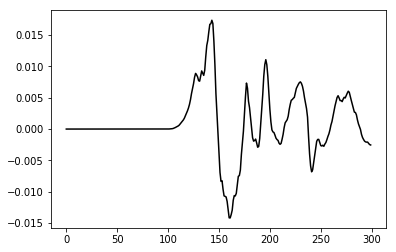

In [10]:
plt.plot(event.raw_image_sensor_response.north.sum(axis=0), color='black')

A power spectrogram of the first few pixel in the camera. They all seem to behave in a similar fashion. The window shape and size of the FFT are arbitrary choices made by me. I chose these values because the look good. I chose a Gaussian window since everything is always gaussian in physics isn't it? I have no clue about signal processing.

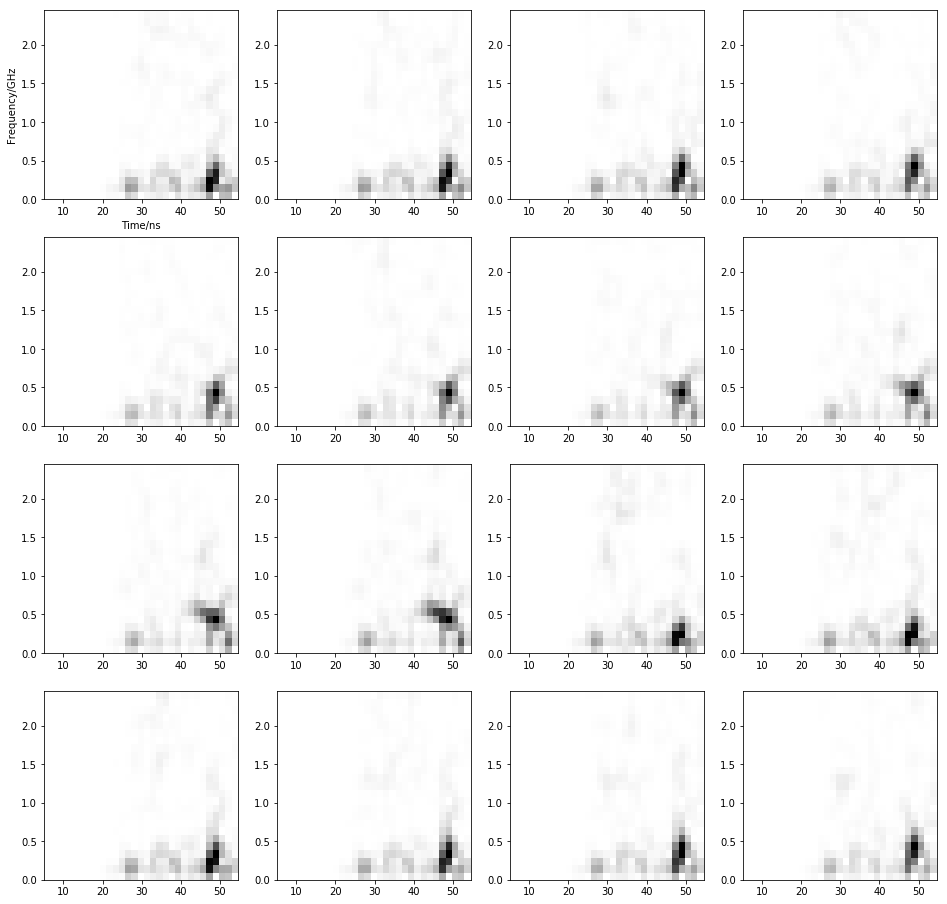

In [8]:
def plot_spectra():
    window_length = 51
    window = signal.gaussian(window_length, std=7)

    fig, axs = plt.subplots(4, 4, figsize=(16, 16))
    axs = np.ravel(axs)
    for pix, ax in enumerate(axs):
        ts = event.raw_image_sensor_response.north[pix, :]
        f, t, Sxx = signal.spectrogram(ts, sampling_frequency.si.value, window=window, nperseg=window_length, noverlap=window_length-8)

        ax.pcolormesh(t*1E9, f/1E9, Sxx, cmap='gray_r')

    axs[0].set_ylabel('Frequency/GHz')
    axs[0].set_xlabel('Time/ns')

plot_spectra()